In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.max_rows", None)


In [2]:
from sklearn.datasets import fetch_openml

ames = fetch_openml(name="house_prices", as_frame=True)
data = ames.frame

In [3]:
data.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [4]:
print(data.shape,data.keys())

(1460, 81) Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 

In [5]:
(data.isnull().mean() * 100).sort_values(ascending=False)


PoolQC           99.520548
MiscFeature      96.301370
Alley            93.767123
Fence            80.753425
FireplaceQu      47.260274
LotFrontage      17.739726
GarageFinish      5.547945
GarageQual        5.547945
GarageYrBlt       5.547945
GarageType        5.547945
GarageCond        5.547945
BsmtExposure      2.602740
BsmtFinType2      2.602740
BsmtCond          2.534247
BsmtFinType1      2.534247
BsmtQual          2.534247
MasVnrArea        0.547945
MasVnrType        0.547945
Electrical        0.068493
Condition2        0.000000
BldgType          0.000000
Neighborhood      0.000000
LandSlope         0.000000
LotConfig         0.000000
Condition1        0.000000
LandContour       0.000000
LotShape          0.000000
Street            0.000000
LotArea           0.000000
MSSubClass        0.000000
MSZoning          0.000000
Id                0.000000
Utilities         0.000000
HouseStyle        0.000000
Foundation        0.000000
ExterQual         0.000000
ExterCond         0.000000
B

In [6]:
#Handling Pool Data
data["PoolQC"] = data["PoolQC"].fillna("None")

#handling Miscellaneous features
data["MiscFeature"] = data["MiscFeature"].fillna("None")

data["Alley"] = data["Alley"].fillna("None")

data["Fence"] = data["Fence"].fillna("None")

data["FireplaceQu"] = data["FireplaceQu"].fillna("None")

#this is not none so used median
data["LotFrontage"] = data.groupby("Neighborhood")["LotFrontage"].transform(lambda x: x.fillna(x.median()))

garage_cat = [
    "GarageQual", "GarageType",
    "GarageFinish", "GarageCond"
]

for col in garage_cat:
    data[col] = data[col].fillna("None")
    
data["GarageYrBlt"] = data["GarageYrBlt"].fillna(0)

bsmt_cols = [
    "BsmtExposure", "BsmtFinType2",
    "BsmtCond", "BsmtFinType1",
    "BsmtQual"
]

for col in bsmt_cols:
    data[col] = data[col].fillna("None")

data["HasBasement"] = (data["BsmtQual"] != "None").astype(int)

data["MasVnrType"] = data["MasVnrType"].fillna("None")
data["MasVnrArea"] = data["MasVnrArea"].fillna(0)

data["Electrical"] = data["Electrical"].fillna(
    data["Electrical"].mode()[0]
)


In [7]:
(data.isnull().mean() * 100).sort_values(ascending=False)


Id               0.0
MSSubClass       0.0
MSZoning         0.0
LotFrontage      0.0
LotArea          0.0
Street           0.0
Alley            0.0
LotShape         0.0
LandContour      0.0
Utilities        0.0
LotConfig        0.0
LandSlope        0.0
Neighborhood     0.0
Condition1       0.0
Condition2       0.0
BldgType         0.0
HouseStyle       0.0
OverallQual      0.0
OverallCond      0.0
YearBuilt        0.0
YearRemodAdd     0.0
RoofStyle        0.0
RoofMatl         0.0
Exterior1st      0.0
Exterior2nd      0.0
MasVnrType       0.0
MasVnrArea       0.0
ExterQual        0.0
ExterCond        0.0
Foundation       0.0
BsmtQual         0.0
BsmtCond         0.0
BsmtExposure     0.0
BsmtFinType1     0.0
BsmtFinSF1       0.0
BsmtFinType2     0.0
BsmtFinSF2       0.0
BsmtUnfSF        0.0
TotalBsmtSF      0.0
Heating          0.0
HeatingQC        0.0
CentralAir       0.0
Electrical       0.0
1stFlrSF         0.0
2ndFlrSF         0.0
LowQualFinSF     0.0
GrLivArea        0.0
BsmtFullBath 

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 82 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          1460 non-null   object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [9]:
X = data.drop(columns="SalePrice")
y = data["SalePrice"]
y = np.log1p(y)

In [10]:
X = pd.get_dummies(X, drop_first=True)

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [32]:
postman_input = X.iloc[0].to_json()
postman_input

'{"Id":1,"MSSubClass":60,"LotFrontage":65.0,"LotArea":8450,"OverallQual":7,"OverallCond":5,"YearBuilt":2003,"YearRemodAdd":2003,"MasVnrArea":196.0,"BsmtFinSF1":706,"BsmtFinSF2":0,"BsmtUnfSF":150,"TotalBsmtSF":856,"1stFlrSF":856,"2ndFlrSF":854,"LowQualFinSF":0,"GrLivArea":1710,"BsmtFullBath":1,"BsmtHalfBath":0,"FullBath":2,"HalfBath":1,"BedroomAbvGr":3,"KitchenAbvGr":1,"TotRmsAbvGrd":8,"Fireplaces":0,"GarageYrBlt":2003.0,"GarageCars":2,"GarageArea":548,"WoodDeckSF":0,"OpenPorchSF":61,"EnclosedPorch":0,"3SsnPorch":0,"ScreenPorch":0,"PoolArea":0,"MiscVal":0,"MoSold":2,"YrSold":2008,"HasBasement":1,"MSZoning_FV":false,"MSZoning_RH":false,"MSZoning_RL":true,"MSZoning_RM":false,"Street_Pave":true,"Alley_None":true,"Alley_Pave":false,"LotShape_IR2":false,"LotShape_IR3":false,"LotShape_Reg":true,"LandContour_HLS":false,"LandContour_Low":false,"LandContour_Lvl":true,"Utilities_NoSeWa":false,"LotConfig_CulDSac":false,"LotConfig_FR2":false,"LotConfig_FR3":false,"LotConfig_Inside":true,"LandSlope_

In [12]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [13]:
X_train = scaler.fit_transform(X_train)

In [14]:
X_test = scaler.transform(X_test)

Model Training

In [15]:
from sklearn.linear_model import LinearRegression

regression = LinearRegression()
regression.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [16]:
print(regression.coef_)

[-5.48335746e-04 -2.10647437e-02  4.38809496e-03  2.39816909e-02
  5.53143047e-02  3.93629516e-02  6.02496718e-02  2.37559584e-02
  5.29514028e-03  2.88120448e-02  8.23276550e-03  4.38997845e-03
  3.74171944e-02  3.71052280e-02  4.36064266e-02  8.98191242e-03
  6.47288158e-02  1.40637132e-02  1.79020092e-03  8.24081004e-03
  1.34511074e-02  1.15726122e-02 -1.17701941e-02  5.60165169e-03
  1.18465218e-02 -1.31585260e-01  6.70796090e-03  3.31269093e-02
  1.16231927e-02  9.03939934e-04  6.12944653e-03  6.41195092e-03
  1.17977623e-02  1.76697457e-01  1.55252963e-03 -1.18515678e-03
 -3.51539842e-03 -8.77540866e-04  7.31551145e-02  3.92450839e-02
  1.32401022e-01  1.06457241e-01  2.65476171e-03 -5.14107055e-03
  1.82124046e-03  5.86043153e-03  2.34267903e-03  2.75685101e-03
  7.34529629e-03  2.35178243e-04  8.58864571e-03 -6.59563782e-03
  7.39020511e-03 -7.10235244e-03 -7.22140718e-03 -6.01042120e-03
 -1.00596112e-03 -1.33743446e-02 -3.35333560e-03 -1.11026415e-02
 -3.90215393e-03  1.02818

In [17]:
regression.intercept_

np.float64(12.030658310971573)

In [18]:
preds = regression.predict(X_test)
# real_prices = np.expm1(preds)


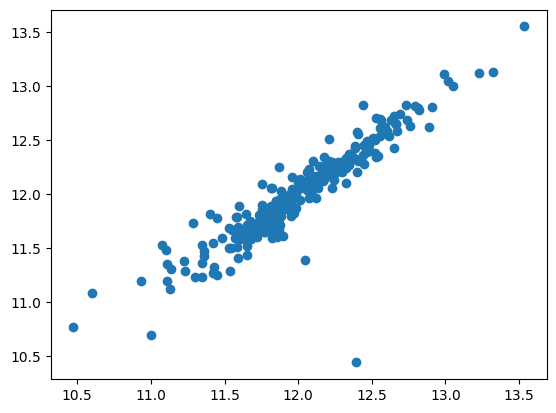

In [19]:
plt.scatter(y_test, preds)

In [20]:
residuals = y_test - preds

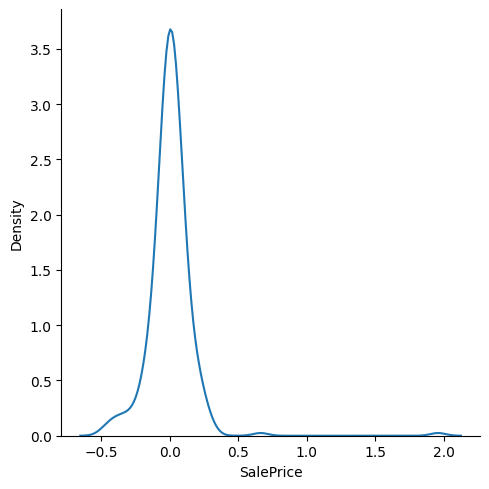

In [23]:
import seaborn as sns

sns.displot(residuals, kind="kde")

In [24]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

y_test_real = np.expm1(y_test)
real_prices = np.expm1(preds)


print("Mean Square Error : ", mean_squared_error(y_test_real, real_prices))
print("Mean Absolute Error : ", mean_absolute_error(y_test_real, real_prices))
print("R2 Score : ", r2_score(y_test_real, real_prices))

Mean Square Error :  648280694.0414467
Mean Absolute Error :  15540.0603406649
R2 Score :  0.9154819917001699


In [25]:
y_test_real[:5], real_prices[:5]

(892     154500.0
 1105    325000.0
 413     115000.0
 522     159000.0
 1036    315500.0
 Name: SalePrice, dtype: float64,
 array([153454.31709552, 340706.9624499 , 100470.14005327, 165194.62621358,
        311551.05863753]))

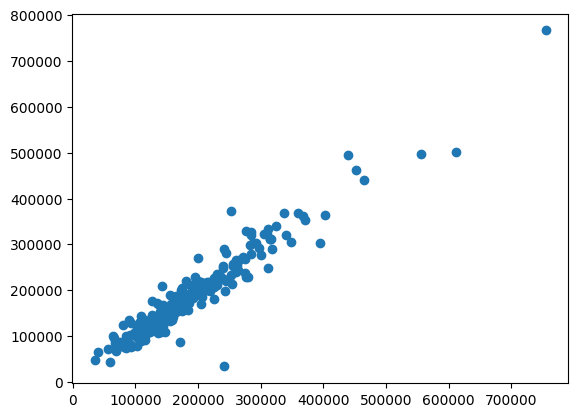

In [26]:
plt.scatter(y_test_real, real_prices)

Manual Testing to check how's my model performing

In [27]:
idx = 0

# take row
row = X.iloc[[idx]]

# scale it
row_scaled = scaler.transform(row)

# predict (log price)
log_pred = regression.predict(row_scaled)[0]

# convert to real price
pred_price = np.expm1(log_pred)

# actual real price
actual_price = data["SalePrice"].iloc[idx]

pred_price, actual_price

(np.float64(206310.42796486014), np.int64(208500))

Pickling the Model File for Deployment

In [30]:
import pickle

pickle.dump(regression, open("regmodel.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))


## Basic Model with 8-10 Important Features

In [33]:
# Select 8-10 important features for basic model
# Important numeric features for house price prediction
important_features = [
    'OverallQual',      # Overall material and finish quality
    'GrLivArea',        # Above grade living area
    'GarageCars',       # Number of garage cars
    'TotalBsmtSF',      # Total basement square feet
    'YearBuilt',        # Original construction date
    'FullBath',         # Full bathrooms above grade
    'TotRmsAbvGrd',     # Total rooms above grade
    '1stFlrSF',         # First floor square feet
    'GarageArea',       # Garage area in square feet
]

# Reload data for basic model
from sklearn.datasets import fetch_openml
ames_basic = fetch_openml(name="house_prices", as_frame=True)
data_basic = ames_basic.frame

# Handle missing values in features
data_basic['GarageArea'] = data_basic['GarageArea'].fillna(0)
data_basic['GarageCars'] = data_basic['GarageCars'].fillna(0)
data_basic['TotalBsmtSF'] = data_basic['TotalBsmtSF'].fillna(0)

# Select features and target
X_basic = data_basic[important_features].copy()
y_basic = data_basic['SalePrice'].copy()
y_basic = np.log1p(y_basic)

print("Basic model features shape:", X_basic.shape)
print("Features:", X_basic.columns.tolist())
print("Missing values:\n", X_basic.isnull().sum())


Basic model features shape: (1460, 9)
Features: ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'YearBuilt', 'FullBath', 'TotRmsAbvGrd', '1stFlrSF', 'GarageArea']
Missing values:
 OverallQual     0
GrLivArea       0
GarageCars      0
TotalBsmtSF     0
YearBuilt       0
FullBath        0
TotRmsAbvGrd    0
1stFlrSF        0
GarageArea      0
dtype: int64


In [34]:
# Train-test split for basic model
X_train_basic, X_test_basic, y_train_basic, y_test_basic = train_test_split(
    X_basic, y_basic, test_size=0.2, random_state=42
)

# Scale the data
scaler_basic = StandardScaler()
X_train_basic_scaled = scaler_basic.fit_transform(X_train_basic)
X_test_basic_scaled = scaler_basic.transform(X_test_basic)

# Train basic model
model_basic = LinearRegression()
model_basic.fit(X_train_basic_scaled, y_train_basic)

print("Basic model trained successfully!")
print("Coefficients:", model_basic.coef_)
print("Intercept:", model_basic.intercept_)


Basic model trained successfully!
Coefficients: [ 0.14124236  0.11243098  0.06182693  0.02673778  0.07649155 -0.00803163
  0.00969818  0.02329423  0.00930299]
Intercept: 12.030658310971573


In [35]:
# Evaluate basic model
preds_basic = model_basic.predict(X_test_basic_scaled)
y_test_real_basic = np.expm1(y_test_basic)
preds_real_basic = np.expm1(preds_basic)

mse_basic = mean_squared_error(y_test_real_basic, preds_real_basic)
mae_basic = mean_absolute_error(y_test_real_basic, preds_real_basic)
r2_basic = r2_score(y_test_real_basic, preds_real_basic)

print("Basic Model Performance:")
print(f"Mean Squared Error: {mse_basic}")
print(f"Mean Absolute Error: {mae_basic}")
print(f"R² Score: {r2_basic}")


Basic Model Performance:
Mean Squared Error: 1009268553.0498883
Mean Absolute Error: 20764.953378587707
R² Score: 0.8684190833886309


In [36]:
# Save basic model and scaler
pickle.dump(model_basic, open("basic_model.pkl", "wb"))
pickle.dump(scaler_basic, open("basic_scaler.pkl", "wb"))
print("Basic model and scaler saved successfully!")


Basic model and scaler saved successfully!
